# Data Analysis of Instance Generation

In [40]:
from bargain import read_h5
from bargain.coalitions import encode_coalition, yield_coalitions

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style = "ticks")
palette = 'viridis'

In [41]:
path = "instances.h5"
datasets = ['instance', 'assignments', 'char_function', 'shapley', 'nucleolus']
data = read_h5(path, datasets)

Let's have a look at the characteristic function.

Text(0.5, 1.0, 'Characteristic function')

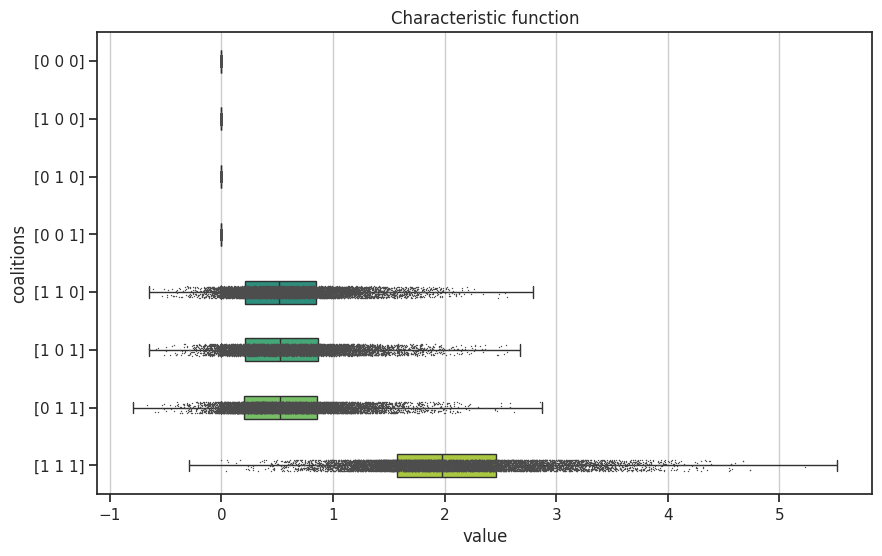

In [42]:
char_function = data['char_function']
char_dict = {}

for i, coalition in enumerate(yield_coalitions(players = [0, 1, 2])):
    coalition = encode_coalition(coalition, n_depots = 3)
    char_dict[str(coalition)] = char_function[:, i]

char_pd = pd.DataFrame(char_dict)
char_pd = char_pd.melt(var_name = 'coalitions', value_name = 'value')

f, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data = char_pd, x = 'value', y = 'coalitions', hue = 'coalitions',
            width = .4, whis = 100, palette = palette)
sns.stripplot(data = char_pd, x = 'value', y = 'coalitions',
              size = 1, color = '.3')
ax.xaxis.grid(True)
ax.set_title('Characteristic function')

Text(0.5, 1.0, 'Shapley value')

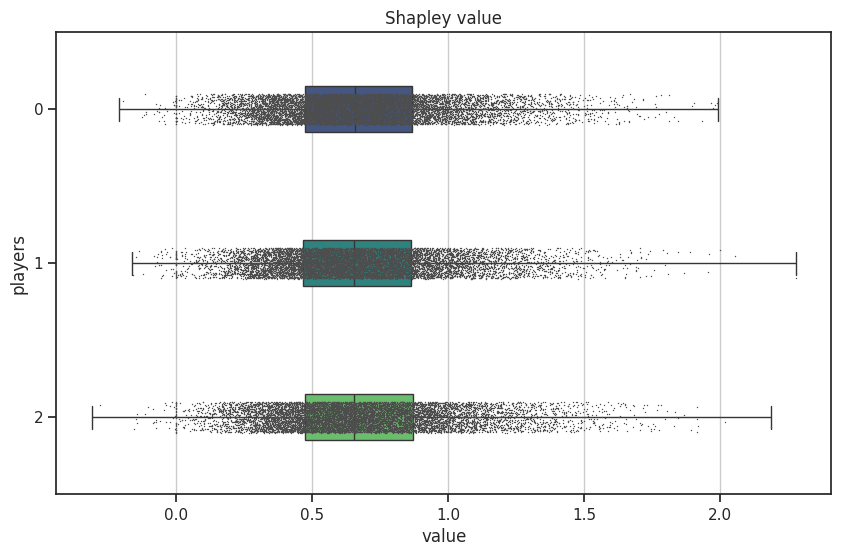

In [43]:
n_players = 3
shap = data['shapley']
shap_dict = {}

for player_id in range(n_players):
    shap_dict[str(player_id)] = shap[:, player_id]

shap_pd = pd.DataFrame(shap_dict)
shap_pd = shap_pd.melt(var_name = 'players', value_name = 'value')

f, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data = shap_pd, x = 'value', y = 'players', hue = 'players',
            width = .3, whis = 100, palette = palette)
sns.stripplot(data = shap_pd, x = 'value', y = 'players',
              size = 1, color = '.3')
ax.xaxis.grid(True)
ax.set_title('Shapley value')

Text(0.5, 1.0, 'Nucleolus')

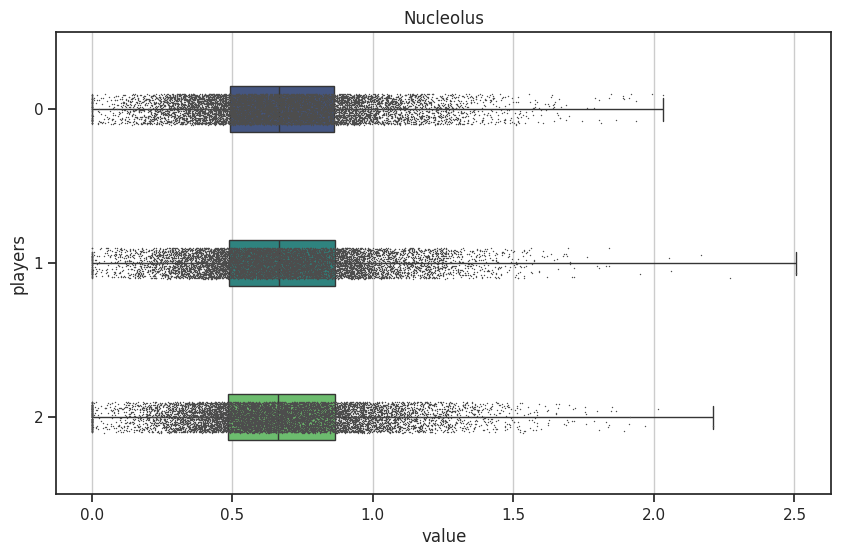

In [44]:
n_players = 3
nucl = data['nucleolus']
nucl_dict = {}

for player_id in range(n_players):
    nucl_dict[str(player_id)] = nucl[:, player_id]

nucl_pd = pd.DataFrame(nucl_dict)
nucl_pd = nucl_pd.melt(var_name = 'players', value_name = 'value')

f, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data = nucl_pd, x = 'value', y = 'players', hue = 'players',
            width = .3, whis = 100, palette = palette)
sns.stripplot(data = nucl_pd, x = 'value', y = 'players',
              size = 1, color = '.3')
ax.xaxis.grid(True)
ax.set_title('Nucleolus')

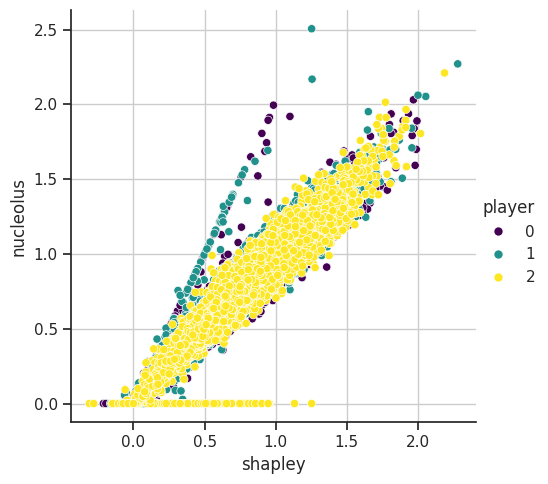

In [39]:
sol_dict = {'shapley': [], 'nucleolus': [], 'player': []}
players = range(n_players)
for i in players:
    sol_dict['shapley'] = sol_dict['shapley'] + list(shap_dict[str(i)])
    sol_dict['nucleolus'] = sol_dict['nucleolus'] + list(nucl_dict[str(i)])
    sol_dict['player'] = sol_dict['player'] + [i] * len(nucl_dict[str(i)])

sol_pd = pd.DataFrame(sol_dict)
g = sns.relplot(data = sol_pd, x = 'shapley', y = 'nucleolus', hue = 'player',
                palette = palette, sizes = (10, 200))
g.ax.xaxis.grid(True)
g.ax.yaxis.grid(True)